# 05 — Data & Model Exploration

Part 1: **data readiness**. Before touching the model again, we look at the exact matrix the
models/API consume — `build_features()` -> `(X, y, meta)` — to check shape, feature types,
distributions, Elo health, missingness, ingest losses, and class balance over time.

We are investigating *why the model predicts 0 draws*; this first part asks whether the **data**
is even in a state to be modelled. Findings written up separately once all cells are run.

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable (this notebook lives in notebooks/)
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.build_features import build_features

# Shared conventions (match notebooks 03/04)
LABEL_ORDER = ["HW", "D", "AW"]
LABEL_NAMES = {"HW": "Home win", "D": "Draw", "AW": "Away win"}
PALETTE = {"HW": "#2a9d8f", "D": "#e9c46a", "AW": "#e76f51"}

# save_schema=False: we are exploring, never overwrite the locked feature schema artifact.
X, y, meta = build_features(save_schema=False)
print("X:", X.shape, " y:", y.shape, " meta:", meta.shape)

X: (1140, 34)  y: (1140,)  meta: (1140, 5)


## 1. Shape & schema check

In [13]:
# Confirm the live matrix matches the locked 34-column schema the models trained on.
import json
schema = json.load(open(ROOT / "artifacts" / "feature_schema.json"))
schema_cols = schema["feature_columns"]

print(f"X columns: {X.shape[1]}   schema columns: {len(schema_cols)}")
print("columns match schema exactly:", list(X.columns) == schema_cols)
print("class balance:\n", y.value_counts())
print("date range:", meta["date"].min(), "->", meta["date"].max())
X.head()

X columns: 34   schema columns: 34
columns match schema exactly: True
class balance:
 result
HW    492
AW    369
D     279
Name: count, dtype: int64[pyarrow]
date range: 2023-08-11 19:00:00+00:00 -> 2026-05-24 15:00:00+00:00


,home_rolling_win_rate,home_rolling_goals_for_avg,home_rolling_goals_against_avg,home_rolling_win_rate_home,home_rolling_win_rate_away,home_rolling_goals_for_home,home_rolling_goals_for_away,home_rolling_goals_against_home,home_rolling_goals_against_away,home_rolling_points_per_game,...,away_rolling_goal_difference_per_game,away_rolling_clean_sheet_rate,away_days_rest,away_is_new_team,home_league_position,away_league_position,home_position_diff,elo_home_pre,elo_away_pre,elo_diff
0,0.380288,1.497679,1.491899,0.434117,0.329857,1.616998,1.385271,1.373633,1.607081,1.383296,...,0.00578,0.233459,7.0,1,10,10,0,1450.0,1450.0,0.0
1,0.380288,1.497679,1.491899,0.434117,0.329857,1.616998,1.385271,1.373633,1.607081,1.383296,...,0.00578,0.233459,7.0,1,10,10,0,1450.0,1450.0,0.0
2,0.380288,1.497679,1.491899,0.434117,0.329857,1.616998,1.385271,1.373633,1.607081,1.383296,...,0.00578,0.233459,7.0,1,10,10,0,1450.0,1450.0,0.0
3,0.380288,1.497679,1.491899,0.434117,0.329857,1.616998,1.385271,1.373633,1.607081,1.383296,...,0.00578,0.233459,7.0,1,10,10,0,1450.0,1450.0,0.0
4,0.380288,1.497679,1.491899,0.434117,0.329857,1.616998,1.385271,1.373633,1.607081,1.383296,...,0.00578,0.233459,7.0,1,10,10,0,1450.0,1450.0,0.0


## 2. Numeric vs categorical features + summary stats

In [14]:
# Most features are continuous; only these are binary / integer-ordinal.
binary_cols = ["home_is_new_team", "away_is_new_team"]
ordinal_cols = ["home_league_position", "away_league_position", "home_position_diff"]
categorical_cols = binary_cols + ordinal_cols
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print(f"{len(numeric_cols)} numeric, {len(categorical_cols)} categorical/ordinal")
print("categorical/ordinal:", categorical_cols)
X[numeric_cols].describe().T

29 numeric, 5 categorical/ordinal
categorical/ordinal: ['home_is_new_team', 'away_is_new_team', 'home_league_position', 'away_league_position', 'home_position_diff']


,count,mean,std,min,25%,50%,75%,max
home_rolling_win_rate,1140.0,0.371644,0.252256,0.000000,0.200000,0.400000,0.600000,1.000000
home_rolling_goals_for_avg,1140.0,1.480893,0.654274,0.000000,1.000000,1.400000,1.800000,4.800000
home_rolling_goals_against_avg,1140.0,1.507517,0.634310,0.000000,1.000000,1.400000,2.000000,5.000000
home_rolling_win_rate_home,1140.0,0.434301,0.274548,0.000000,0.200000,0.400000,0.600000,1.000000
home_rolling_win_rate_away,1140.0,0.329629,0.234956,0.000000,0.200000,0.329857,0.400000,1.000000
home_rolling_goals_for_home,1140.0,1.617668,0.713421,0.000000,1.000000,1.600000,2.000000,5.000000
home_rolling_goals_for_away,1140.0,1.384711,0.605505,0.000000,1.000000,1.400000,1.800000,4.000000
home_rolling_goals_against_home,1140.0,1.371352,0.649634,0.000000,1.000000,1.353483,1.762500,4.200000
home_rolling_goals_against_away,1140.0,1.605528,0.642389,0.000000,1.200000,1.600000,2.000000,4.000000
home_rolling_points_per_game,1140.0,1.357997,0.708885,0.000000,0.800000,1.400000,1.800000,3.000000


In [ ]:
# how many matches have >30 days rest for either team?
print((X["away_days_rest"] > 30).sum())
print((X["home_days_rest"] > 30).sum())

19
16


## 3. Distributions

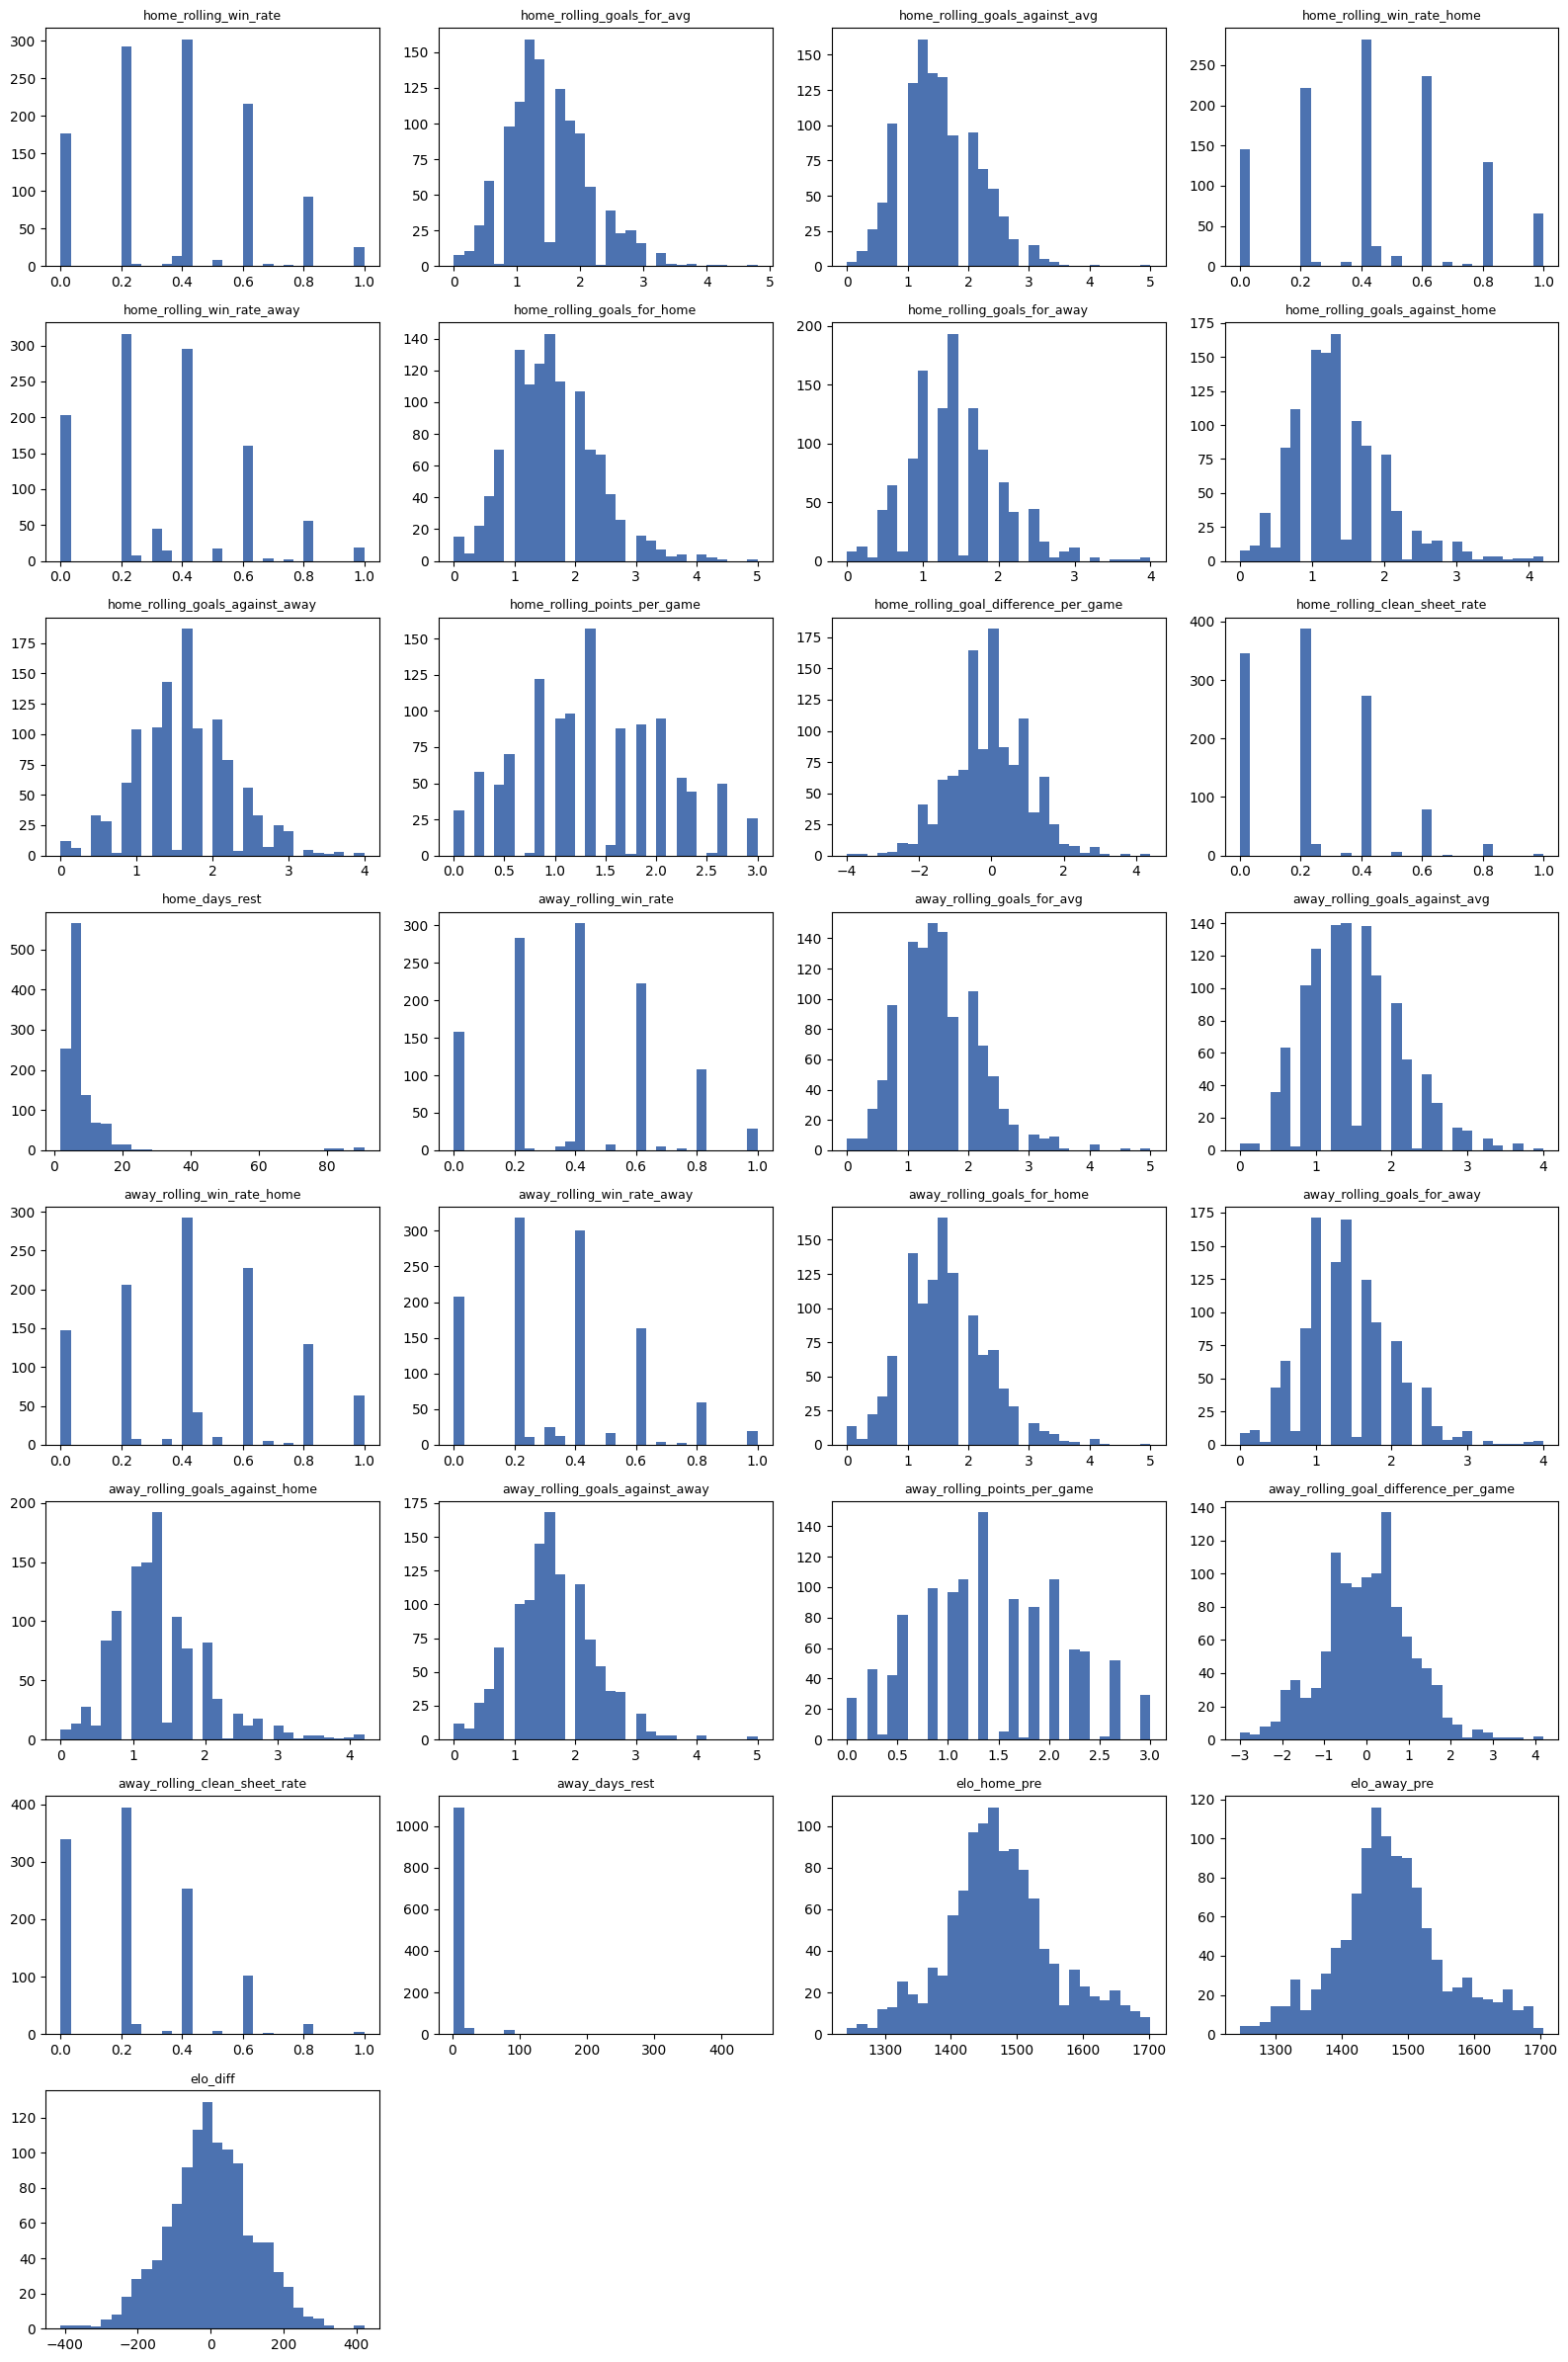

In [15]:
# Histograms for every numeric feature.
ncols = 4
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(X[col].dropna(), bins=30, color="#4c72b0")
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(numeric_cols):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

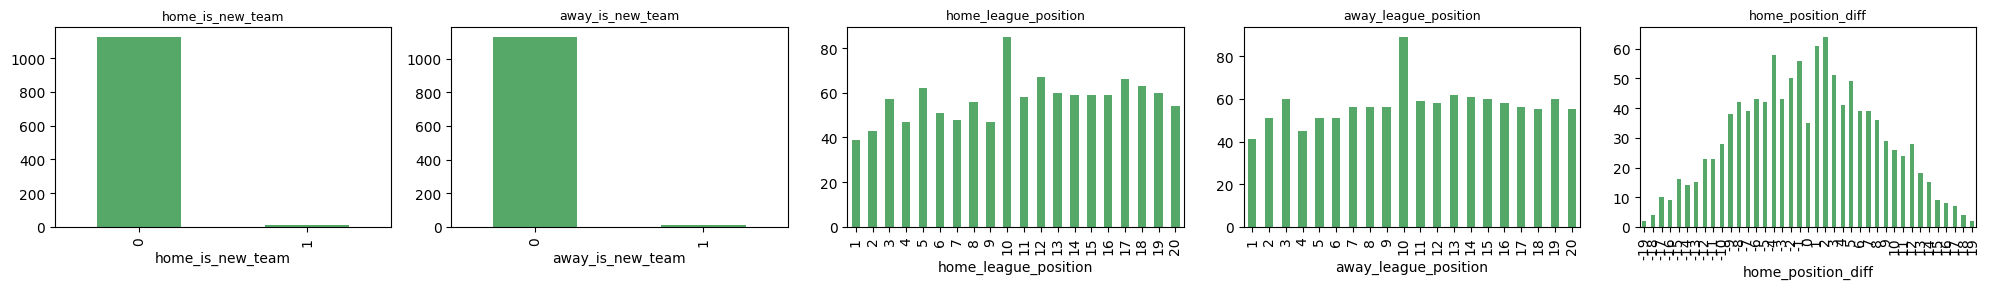

In [16]:
# Value counts for the binary / ordinal features.
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(4 * len(categorical_cols), 3))
for ax, col in zip(axes, categorical_cols):
    X[col].value_counts().sort_index().plot.bar(ax=ax, color="#55a868")
    ax.set_title(col, fontsize=9)
fig.tight_layout()
plt.show()

In [22]:
print("home_is_new_team == 1:", (X["home_is_new_team"] == 1).sum())
print("away_is_new_team == 1:", (X["away_is_new_team"] == 1).sum())

home_is_new_team == 1: 14
away_is_new_team == 1: 11


### What's happening: 
The flags are only firing for genuinely promoted teams (those starting at Elo 1450 with zero history), not for every team whose first appearance in the dataset triggers rolling feature imputation. Result is 25 flagged rows across 3 seasons when you'd expect ~60. The imputation itself is still applied correctly, the flag just isn't marking those rows so the model can't use it as a signal.
Quick fix: In src/features/rolling.py, change the flag logic from checking whether a team is on a "promoted teams" list to checking whether the team has any prior match history at the time of the current match. 

Any team whose rolling window is empty at match time gets flagged, regardless of whether they're promoted or just appearing for the first time in the dataset window.


## 4. Rolling Elo over time (2023-2025)

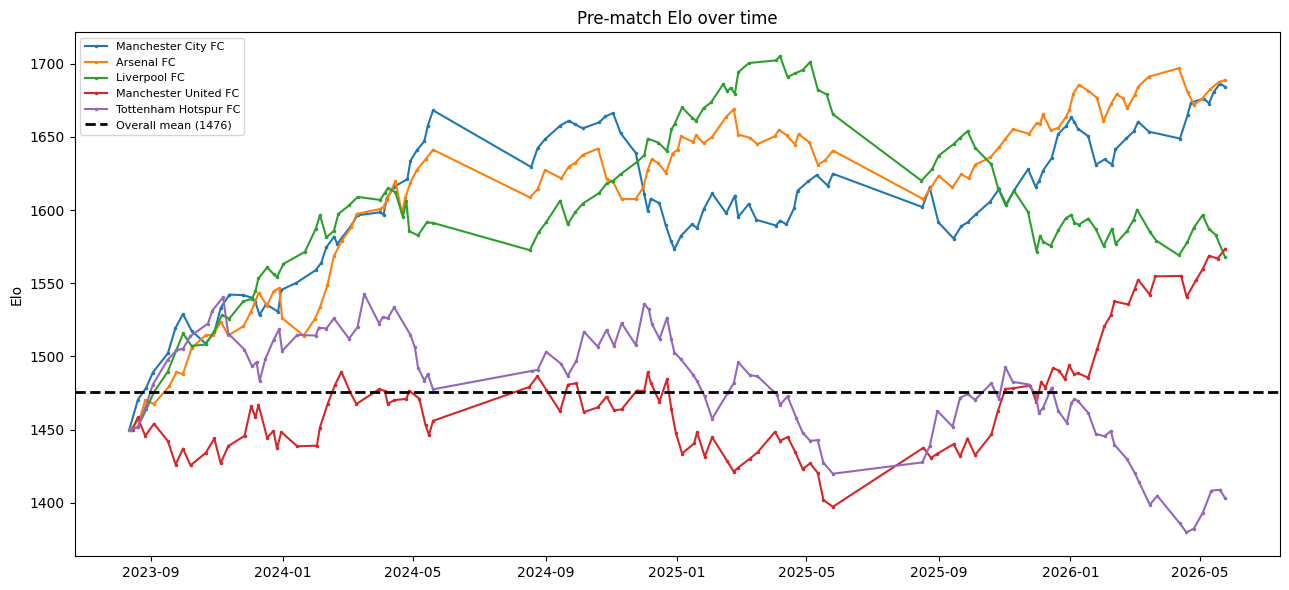

Elo overall - mean: 1475.5  min: 1242.4  max: 1705.2


In [23]:
# Reshape pre-match Elo into one row per (team, date) so we can trace trajectories.
home = meta[["date", "home_team"]].assign(elo=X["elo_home_pre"].values)
home.columns = ["date", "team", "elo"]
away = meta[["date", "away_team"]].assign(elo=X["elo_away_pre"].values)
away.columns = ["date", "team", "elo"]
elo_long = pd.concat([home, away]).sort_values("date")

fig, ax = plt.subplots(figsize=(13, 6))
# A few recognisable teams for readability, plus the league-wide mean (should stay ~1500).
for team in ["Manchester City FC", "Arsenal FC", "Liverpool FC",
             "Manchester United FC", "Tottenham Hotspur FC"]:
    t = elo_long[elo_long["team"] == team]
    if len(t):
        ax.plot(t["date"], t["elo"], marker=".", ms=3, label=team)
mean_by_date = elo_long.groupby("date")["elo"].mean()
overall_mean = elo_long["elo"].mean()
ax.axhline(overall_mean, color="black", lw=2, ls="--", label=f"Overall mean ({overall_mean:.0f})")

ax.set_title("Pre-match Elo over time")
ax.set_ylabel("Elo")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("Elo overall - mean:", round(elo_long["elo"].mean(), 1),
      " min:", round(elo_long["elo"].min(), 1),
      " max:", round(elo_long["elo"].max(), 1))

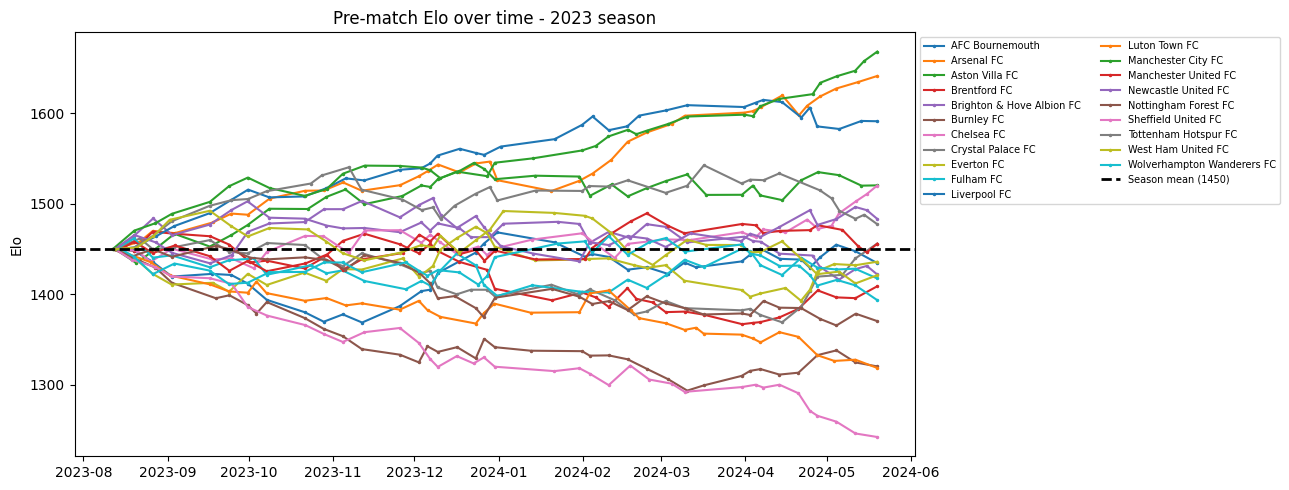

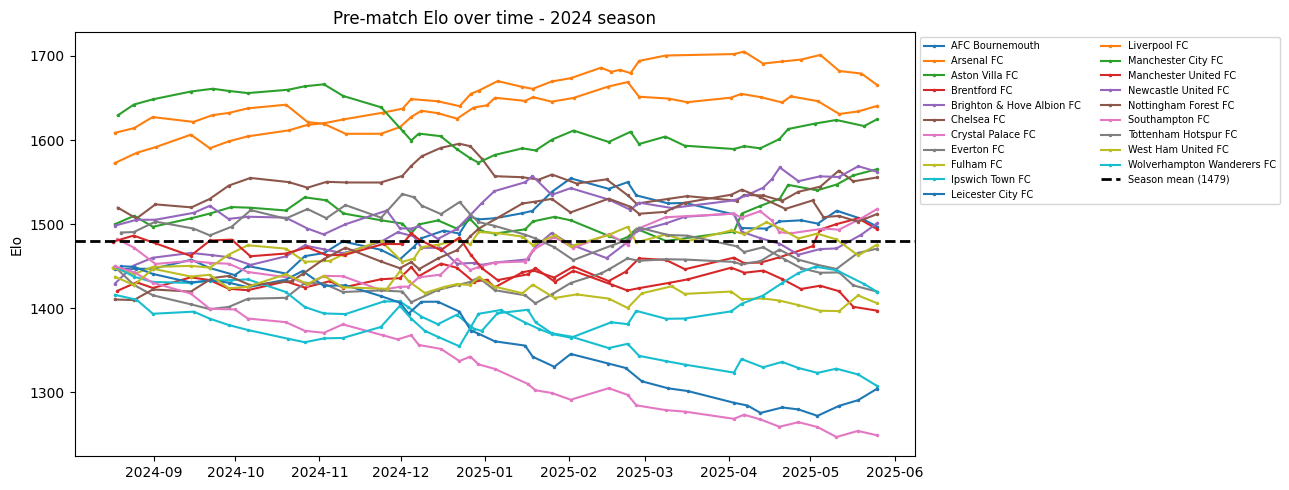

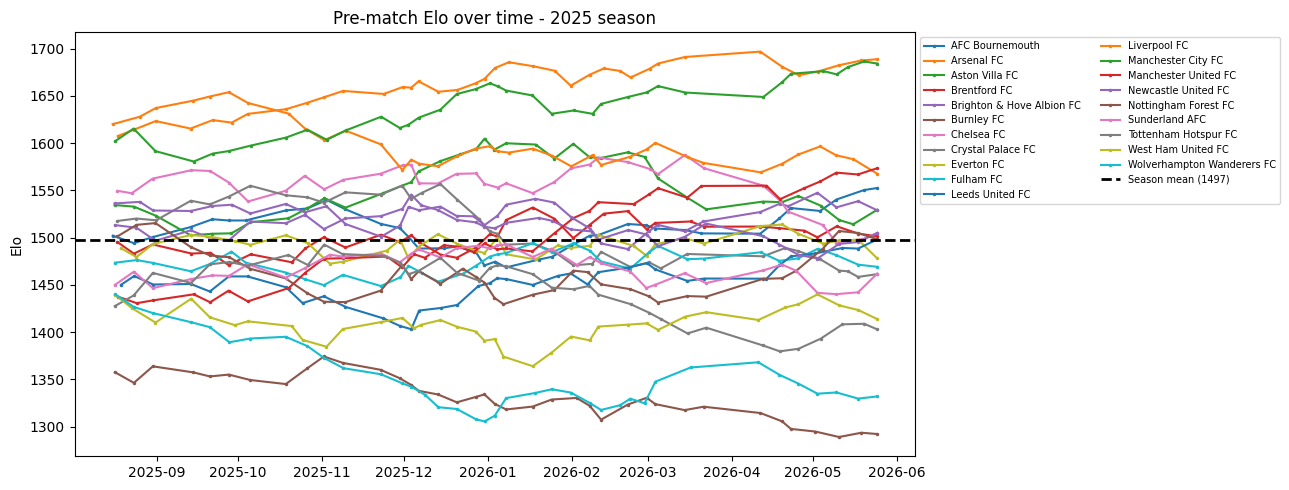

In [19]:
# Same Elo, but one figure per season: every team's trajectory within that season.
home_s = meta[["date", "season", "home_team"]].assign(elo=X["elo_home_pre"].values)
home_s.columns = ["date", "season", "team", "elo"]
away_s = meta[["date", "season", "away_team"]].assign(elo=X["elo_away_pre"].values)
away_s.columns = ["date", "season", "team", "elo"]
elo_season = pd.concat([home_s, away_s]).sort_values("date")

for season in sorted(elo_season["season"].unique()):
    s = elo_season[elo_season["season"] == season]
    fig, ax = plt.subplots(figsize=(13, 5))
    for team, t in s.groupby("team"):
        ax.plot(t["date"], t["elo"], marker=".", ms=3, label=team)
    mean_by_date = s.groupby("date")["elo"].mean()
    season_mean = s["elo"].mean()
    ax.axhline(season_mean, color="black", lw=2, ls="--", label=f"Season mean ({season_mean:.0f})")

    ax.set_title(f"Pre-match Elo over time - {season} season")
    ax.set_ylabel("Elo")
    ax.legend(fontsize=7, ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0))
    fig.tight_layout()
    plt.show()

## 5. Missingness / warm-up audit
Rolling features are undefined for each team's first games — check how much of the matrix is NaN or zero-filled.

In [8]:
na = X.isna().sum()
zero = (X == 0).sum()
audit = pd.DataFrame({
    "n_missing": na,
    "pct_missing": (na / len(X) * 100).round(1),
    "n_zero": zero,
    "pct_zero": (zero / len(X) * 100).round(1),
}).sort_values("pct_missing", ascending=False)
print("rows:", len(X))
audit

rows: 1140


,n_missing,pct_missing,n_zero,pct_zero
home_rolling_win_rate,0,0.0,177,15.5
away_rolling_clean_sheet_rate,0,0.0,339,29.7
away_rolling_goals_for_home,0,0.0,14,1.2
away_rolling_goals_for_away,0,0.0,9,0.8
away_rolling_goals_against_home,0,0.0,8,0.7
away_rolling_goals_against_away,0,0.0,12,1.1
away_rolling_points_per_game,0,0.0,27,2.4
away_rolling_goal_difference_per_game,0,0.0,87,7.6
away_days_rest,0,0.0,0,0.0
home_rolling_goals_for_avg,0,0.0,8,0.7


### What's happening (issue): 

No NaNs in the feature matrix, imputation is working. However home_rolling_clean_sheet_rate (30.4% zeros) and away_rolling_clean_sheet_rate (29.7% zeros) are high enough that a genuine zero and an imputed zero are indistinguishable. Same applies to win rate features (13-18% zeros). The model can't tell the difference between a team that genuinely kept no clean sheets in their last 5 games vs a team whose value was zero-filled due to no prior history.
Quick fix: This is already partially addressed by the is_new_team flag, but since that flag is undercounting (previous issue), fixing the is_new_team flag is the real solution here. Once that's fixed, the model has a signal to discount zero values for teams with no history. No separate fix needed beyond that.

## 6. Validation report & quarantine

In [9]:
# What did ingest drop on the way to the canonical dataset?
report = json.load(open(ROOT / "data" / "processed" / "validation_report.json"))
print(json.dumps(report, indent=2))

quarantine = ROOT / "data" / "quarantine"
if quarantine.exists():
    files = list(quarantine.glob("*"))
    print(f"\nquarantine files: {len(files)}", [f.name for f in files])
else:
    print("\nno quarantine directory")

{
  "generated_at": "2026-06-05T02:54:58.387102+00:00",
  "schema": {
    "missing_columns": [],
    "dtype_mismatches": {}
  },
  "total_rows": 1140,
  "rows_kept": 1140,
  "rows_dropped": 0,
  "dropped_by_reason": {},
  "by_season": {
    "2023": {
      "kept": 380,
      "dropped": 0
    },
    "2024": {
      "kept": 380,
      "dropped": 0
    },
    "2025": {
      "kept": 380,
      "dropped": 0
    }
  }
}

quarantine files: 1 ['dropped_2025.parquet']


## 7. Class balance over time

outcome share by season:
 result     HW      D     AW
season                     
2023    0.461  0.216  0.324
2024    0.408  0.245  0.347
2025    0.426  0.274  0.300

overall:
 result
HW    0.432
AW    0.324
D     0.245
Name: proportion, dtype: double[pyarrow]


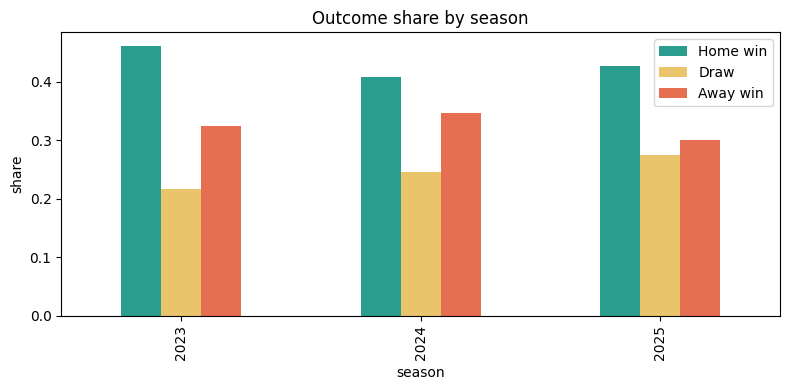

In [24]:
# Is the ~26% draw rate stable across seasons, or drifting?
by_season = pd.crosstab(meta["season"], y, normalize="index")[LABEL_ORDER].round(3)
print("outcome share by season:\n", by_season)
print("\noverall:\n", y.value_counts(normalize=True).round(3))

by_season.plot.bar(figsize=(8, 4), color=[PALETTE[l] for l in LABEL_ORDER])
plt.title("Outcome share by season")
plt.ylabel("share")
plt.legend([LABEL_NAMES[l] for l in LABEL_ORDER])
plt.tight_layout()
plt.show()

### Issue: Draw rate increasing season-on-season (distributional shift)
What's happening: Draw frequency is rising consistently across the three seasons: 2023 at 21.6%, 2024 at 24.5%, 2025 at 27.4%. This is a distributional shift in the target variable over time. Because your walk-forward backtest trains on earlier seasons and tests on later ones, the model is systematically undertrained on draws relative to how frequently they appear in the test periods. The model learns draw rates from a lower-draw-rate world and gets evaluated on an increasingly draw-heavy one.
This is not a data quality problem but it is a meaningful limitation. The data accurately reflects what happened in those seasons, draws just genuinely became more common.
Why it matters for your model: The model's already weak draw signal gets further penalised because the training distribution doesn't match the test distribution for the draw class specifically. This contributes to the 0 draw predictions seen in the confusion matrix.
What you can do about it: Not much without more data. With only 3 seasons you can't smooth this trend out. Document it as a known limitation. If you added a 4th or 5th season the trend may stabilise. This is also a good argument for why xG data would help, it provides a draw signal that is less sensitive to season-level distributional shifts in outcomes.

### Summary of findings acrross this data exploration

Data is clean and correctly shaped. 1140 rows across 3 seasons (380 per season), 34 features, zero missing values, schema matches exactly. No data quality issues are causing the model's poor performance.

Class imbalance is real but not catastrophic. Draws at 24.5% are the minority class but reflect realistic PL distributions. The model's failure to predict any draws is not caused by imbalance alone, it's a signal problem.

Draw rate is increasing season-on-season (21.6% → 24.5% → 27.4%). This distributional shift means the model trains on lower-draw-rate data and gets tested on progressively more draw-heavy seasons. This is a meaningful contributor to poor draw recall.

Elo system is working correctly. Ratings diverge sensibly within seasons, top teams cluster above 1600, bad teams drop toward 1300, and season regression is visible at each season boundary. The 2023 season has weaker Elo signal because all teams start at 1450 with no prior history.

Promoted team starting Elo of 1450 is a known limitation. It may be too generous for genuinely weak promoted sides, but Elo self-corrects after 5-6 matches and the number of affected rows is small. Worth documenting but not worth fixing now.

home_is_new_team and away_is_new_team flags are undercounting. Only 25 rows flagged across 3 seasons when ~60 are expected. The flag fires for genuinely promoted teams only, not for every team's first appearance in the dataset. Fix: set the flag based on whether the rolling window was empty at match time, not whether the team is on a promoted list.

Days rest outliers exist but are negligible. 19 and 16 rows respectively have days rest above 30, likely COVID gaps or cross-season first appearances. Under 2% of the data, not affecting model performance.

Rolling feature zeros are high for clean sheet rate and win rate but expected. 30% zero clean sheet rate and 13-18% zero win rates reflect genuine football outcomes, not imputation errors. The is_new_team flag fix will help the model distinguish genuine zeros from imputed ones.

Feature distributions are all sensible. Win rates, goals averages, Elo distributions, and position features all look like real PL data. No suspicious spikes, impossible values, or signs of leakage in the distributions.
The draw prediction problem is structural, not a data problem. The data is accurate and the pipeline is clean. Draws are hard to predict with tabular features because goals, form, and Elo look similar for narrow wins and draws. Without xG, the model has no signal that reliably distinguishes these outcomes.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── load backtest predictions ──────────────────────────────────────────────
preds = pd.read_parquet("reports/predictions.parquet")
# expects columns: y_true, p_home, p_draw, p_away
# filter to rf_tuned only
rf = preds[preds["model"] == "rf_tuned"].copy()

y_true   = rf["y_true"].values
p_draw   = rf["p_draw"].values
p_home   = rf["p_home"].values
p_away   = rf["p_away"].values

is_draw     = y_true == "D"
is_non_draw = ~is_draw

# ── 1. distribution of p_draw: draws vs non-draws ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(p_draw[is_draw],     bins=30, alpha=0.7, label=f"Actual draws (n={is_draw.sum()})",     color="#eab308")
ax.hist(p_draw[is_non_draw], bins=30, alpha=0.5, label=f"Non-draws (n={is_non_draw.sum()})", color="#6b7280")
ax.axvline(0.25, color="red", ls="--", lw=1.5, label="0.25 reference")
ax.axvline(0.35, color="orange", ls="--", lw=1.5, label="0.35 reference")
ax.set_xlabel("p_draw")
ax.set_ylabel("count")
ax.set_title("Distribution of p_draw — actual draws vs non-draws (rf_tuned, test set)")
ax.legend()
fig.tight_layout()
plt.show()

# ── 2. summary stats ───────────────────────────────────────────────────────
print("=== p_draw summary ===")
print(f"max p_draw across all 760 matches : {p_draw.max():.4f}")
print(f"mean p_draw on actual draws       : {p_draw[is_draw].mean():.4f}")
print(f"mean p_draw on non-draws          : {p_draw[is_non_draw].mean():.4f}")
print()

# ── 3. where does draw rank in the probability vector? ────────────────────
probs = np.stack([p_home, p_draw, p_away], axis=1)  # shape (n, 3)
# rank 1 = highest, rank 3 = lowest
ranks = probs.shape[1] - np.argsort(np.argsort(probs, axis=1), axis=1)
draw_rank = ranks[:, 1]  # column 1 is p_draw

print("=== draw rank in probability vector (all 760 matches) ===")
for r in [1, 2, 3]:
    n = (draw_rank == r).sum()
    print(f"  draw ranked {r}st/nd/rd : {n:4d}  ({n/len(draw_rank)*100:.1f}%)")
print()

print("=== draw rank on ACTUAL draw matches only ===")
draw_rank_actual = draw_rank[is_draw]
for r in [1, 2, 3]:
    n = (draw_rank_actual == r).sum()
    print(f"  draw ranked {r}st/nd/rd : {n:4d}  ({n/len(draw_rank_actual)*100:.1f}%)")

# ── 4. decision gate ───────────────────────────────────────────────────────
print()
print("=== DECISION GATE ===")
mean_draw_on_draws = p_draw[is_draw].mean()
pct_draw_2nd       = (draw_rank == 2).mean()

if mean_draw_on_draws >= 0.25 and pct_draw_2nd >= 0.40:
    print("✓ p_draw looks healthy on actual draws.")
    print("  This is an argmax/threshold issue, not signal collapse.")
    print("  Brier score is the honest scoreboard. Consider threshold tuning.")
else:
    print("✗ p_draw is suppressed — possible signal collapse.")
    print("  Stages B-D matter more: class weighting, features, or calibration.")

FileNotFoundError: [Errno 2] No such file or directory: 'reports/predictions.parquet'